# Minimal example

This notebooks reproduces the code-blocks and figures from the *basic usage* page.

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

In [2]:
from vassi.config import cfg
# from vassi.features import DataFrameFeatureExtractor
from vassi.classification._predict import predict
from vassi.classification.visualization import (
    plot_confusion_matrix,
    plot_classification_timeline,
)
from vassi.dataset import AnnotatedDataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import compute_sample_weight

from xgboost import XGBClassifier

First, the trajectory data needs to be configured.

The CALMS21 dataset contains posture data (tracked keypoints) and timestamps (frame indices), for which we define named keys in the vassi configuration.

In [3]:
cfg.key_keypoints = "keypoints"
cfg.key_timestamp = "timestamps"

cfg.trajectory_keys = ("keypoints", "timestamps")

## 1. Load training dataset and extract features

If you have not yet downloaded the CALMS21 dataset, you can do so with the following command.

This command runs a module that we provide for convenience to download and convert the CALMS21 dataset. You can execute it here in Jupyter (or directly in the command line), which is equivalent to running the commented code in the cell below.

In [4]:
# !python -m vassi.case_studies.calms21.download --output_directory ../../datasets/CALMS21 --remove-taskprog-features

In [5]:
# # running the above command is equivalent to the following code

# from vassi.case_studies.calms21.download import download_calm21_dataset, convert_calms21_sequences
# from pathlib import Path
# import shutil

# output_directory = Path("../../datasets/CALMS21")

# download_calm21_dataset(
#     output_directory=output_directory,
#     remove_taskprog_features=True,
#     download_videos=False,
# )
# convert_calms21_sequences(
#     output_directory / "task1_classic_classification" / "calms21_task1_train.json",
#     output_directory / "task1_classic_classification" / "calms21_task1_test.json",
#     output_directory,
# )
                                      
# # clean up
# shutil.rmtree(output_directory / "task1_classic_classification")

The dataset can now be imported. First, we only load the training dataset, containing the tracking data and behavioral observations for 70 mouse resident-intruder sequences.

Note that this dataset only contains behavioral observations for the resident mouse, so we exclude the intruders as potential actors below (removes all dyas with 'intruder' as actor).  
This leaves exactly one directed dyad per sequence (number of groups == number of dyads in this dataset).

In [6]:
ad = AnnotatedDataset.load(
    "../../datasets/CALMS21/train/mice_train_trajectories.h5",
    target="dyad",
    observation_file="../../datasets/CALMS21/train/mice_train_annotations.csv",
    background_category="none",
).exclude({"intruder"})

print(f"The CALMS21 training dataset consists of {len(ad)} groups (sequences)")
print(f"and a total of {ad.num_samples} samples (video frames per dyad)")
print(
    f"with the following counts per category:\n{
        "\n".join([f"    {category}: {count}" for category, count in ad.category_counts.items()])
    }"
)

/home/paul/vassi/src/vassi/dataset/types.py:1787: UserWarning: Loading categories (attack, investigation, mount, none) from observations file, specify categories argument if incomplete.


The CALMS21 training dataset consists of 70 groups (sequences)
and a total of 507738 samples (video frames per dyad)
with the following counts per category:
    attack: 14039
    investigation: 146615
    mount: 28615
    none: 318469


In [7]:
from vassi.features import DataFrameExtractor, Extractor

In [8]:
extractor = DataFrameExtractor.from_yaml("features-mice.yaml", cache_mode=True)

for element in [element for _, group in ad for _, element in group]:
    element.sample_X(extractor, indices=None, out=None)

extractor = DataFrameExtractor.from_yaml("features-mice.yaml", cache_mode=False)

In [9]:
import numpy as np
import pandas as pd

dyad = ad[0][("resident", "intruder")]
out = np.zeros((1000, extractor.num_features))
_ = extractor.extract(dyad.trajectory, dyad.trajectory_other, indices=np.arange(1000), out=out)

## 2. Fit classification model

In [13]:
%%time

X, y = ad.subsample(
    extractor,
    size={category: 10000 for category in ad.categories},
    min_samples_per_stratum=1,
    random_state=1,
    reset=False,
    exclude_previously_sampled=False,
    store_indices=False,
    ensure_sampling_at=None,
    out=(None, None),
)

CPU times: user 3.34 s, sys: 218 ms, total: 3.55 s
Wall time: 2.12 s


In [14]:
%%time

classifier = XGBClassifier(n_estimators=10, random_state=1)
classifier.fit(X, y, sample_weight=compute_sample_weight("balanced", y))

CPU times: user 8.64 s, sys: 87.9 ms, total: 8.73 s
Wall time: 1.16 s


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 3. Load test dataset and predict

In [15]:
ad_test = AnnotatedDataset.load(
    "../../datasets/CALMS21/test/mice_test_trajectories.h5",
    target="dyad",
    observation_file="../../datasets/CALMS21/test/mice_test_annotations.csv",
    background_category="none",
).exclude({"intruder"})

print(f"The CALMS21 test dataset consists of {len(ad_test)} groups (sequences)")
print(f"and a total of {ad_test.num_samples} samples (video frames per dyad)")
print(
    f"with the following counts per category:\n{
        "\n".join([f"    {category}: {count}" for category, count in ad_test.category_counts.items()])
    }"
)

/home/paul/vassi/src/vassi/dataset/types.py:1787: UserWarning: Loading categories (attack, investigation, mount, none) from observations file, specify categories argument if incomplete.


The CALMS21 test dataset consists of 19 groups (sequences)
and a total of 262107 samples (video frames per dyad)
with the following counts per category:
    attack: 12630
    investigation: 61275
    mount: 31848
    none: 156354


In [16]:
%%time

result_test = predict(ad_test, classifier, extractor)

CPU times: user 4.61 s, sys: 168 ms, total: 4.77 s
Wall time: 5.51 s


In [17]:
import polars as pl

result_test.f1_score(on="timestamp").select("score").mean().item()

0.7807370955579597

## 4. Visualizations and evaluation

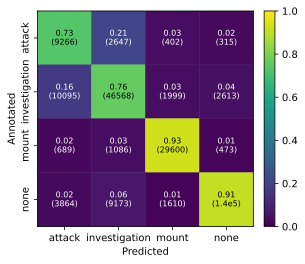

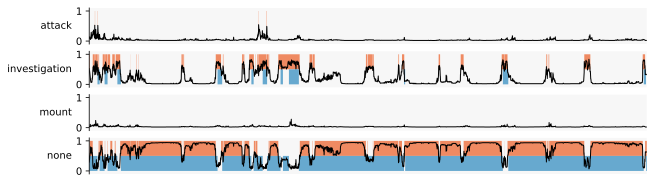

In [18]:
plot_confusion_matrix(
    result_test.y_gt,
    result_test.y,
    category_labels=sorted(result_test.categories),
)

result_dyad = result_test[10][("resident", "intruder")]

plot_classification_timeline(
    result_dyad.predictions,
    annotations=result_dyad.annotations,
    categories=sorted(result_dyad.categories),
    y_proba=result_dyad.y_proba,
    timestamps=result_dyad.timestamps,
)

In [19]:
result_test.to_h5("result_test.h5")

In [20]:
result_test.f1_score("timestamp")

category,on,score
str,str,f64
"""attack""","""timestamp""",0.507115
"""investigation""","""timestamp""",0.771319
"""mount""","""timestamp""",0.904383
"""none""","""timestamp""",0.940132


Compute the F1 score for each category on the per-frame (timestamp) level:

In [21]:
result_test.f1_score("timestamp")

# attack           0.468806
# investigation    0.738400
# mount            0.901669
# none             0.932623
# Name: timestamp, dtype: float64

category,on,score
str,str,f64
"""attack""","""timestamp""",0.507115
"""investigation""","""timestamp""",0.771319
"""mount""","""timestamp""",0.904383
"""none""","""timestamp""",0.940132


This is also available for two other levels, i.e., annotation and prediction intervals.

- when computing scores on prediction intervals, the category of the ground-truth interval with maximum overlap is considered as the true category
- when computing scores on annotation intervals, the category of the predicted interval with maximum overlap is considered as the predicted category

With this in mind, the F1 score of predictions is related to the precision of predicted intervals, whereas the F1 score of annotations is related to the recall of annotated intervals.

In [22]:
result_test.f1_score("annotation")

# attack           0.494450
# investigation    0.684685
# mount            0.822115
# none             0.849611
# Name: annotation, dtype: float64

category,on,score
str,str,f64
"""attack""","""annotation""",0.532731
"""investigation""","""annotation""",0.742279
"""mount""","""annotation""",0.861244
"""none""","""annotation""",0.864671


In [23]:
result_test.f1_score("prediction")

# attack           0.274927
# investigation    0.532850
# mount            0.480562
# none             0.539296
# Name: prediction, dtype: float64

category,on,score
str,str,f64
"""attack""","""prediction""",0.32326
"""investigation""","""prediction""",0.52591
"""mount""","""prediction""",0.43289
"""none""","""prediction""",0.576334


And made available as a summary:

interactive-table is a custom tabular data display that we developed for interactive inspection of behavioral classification results. Here, we use it for a better visualization of pandas DataFrames in our documentation.

Important: note that not all interactive fuctions are executed properly without an active python kernel.

In [25]:
# from interactive_table import Table

# Table(result_test.score())

We later use the unweighted average of all these scores to find optimal postprocessing hyperparameters.

To compare the predictions with the results of other behavioral classification tools using the CALMS21 dataset, we can compute the macro (unweighted average) F1 score of the behavioral foreground categories ('attack', 'investigation' and 'mount'):

In [29]:
macro_f1 = (
    result_test
    .f1_score("timestamp")
    .filter(pl.col("category").is_in(result_test.foreground_categories))
    .get_column("score")
    .mean()
)

macro_f1

# np.float64(0.702958669540446)

0.7276055414440012

Note that this is only a simple model that was trained on a very small subset of the available data for demonstration purposes.

## 5. Postprocessing (smoothing)

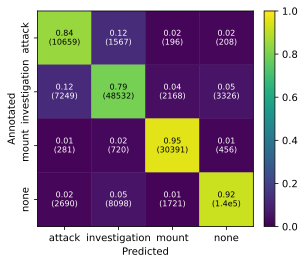

Macro foreground F1 score: 0.7276055414440012 -> 0.786734114849485


In [30]:
from vassi.sliding_metrics import sliding_mean
from functools import partial

result_test_smoothed = result_test.smooth(partial(sliding_mean, window_size=31))

macro_f1_smoothed = (
    result_test_smoothed
    .f1_score("timestamp")
    .filter(pl.col("category").is_in(result_test.foreground_categories))
    .get_column("score")
    .mean()
)

plot_confusion_matrix(
    result_test_smoothed.y_gt,
    result_test_smoothed.y,
    category_labels=sorted(result_test_smoothed.categories),
)

print("Macro foreground F1 score:", macro_f1, "->", macro_f1_smoothed)

In [31]:
result_test_smoothed.f1_score("timestamp")

category,on,score
str,str,f64
"""attack""","""timestamp""",0.636187
"""investigation""","""timestamp""",0.807575
"""mount""","""timestamp""",0.916441
"""none""","""timestamp""",0.945761


As you can see above, simple smoothing with a sliding mean (window size of ~ one second) can already improve the performance of this basic model.

Note that for simplicity, we here just chose a small window size, but this should be ideally tested or optimized on a part of the training dataset (or using cross validation) and *not* on the test dataset to avoid leakage.

In the comparison below, you can see that this improvement is likely associated with a decrease in very short predictions and frequent back-and-forth between predicted categories. Therefore, smoothing may also reduce temporal resolution or accuracy, so it is advisable to tune such hyperparameters carefully.

before smoothing


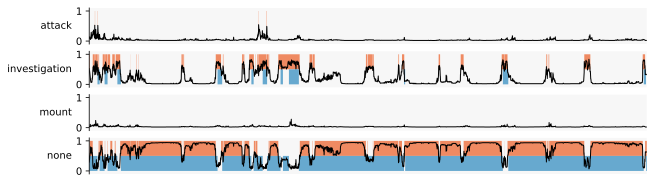

after smoothing


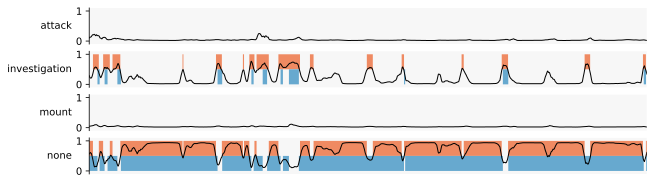

In [34]:
result_dyad_smoothed = result_test_smoothed[10][("resident", "intruder")]

print("before smoothing")
plot_classification_timeline(
    result_dyad.predictions,
    annotations=result_dyad.annotations,
    categories=sorted(result_dyad.categories),
    y_proba=result_dyad.y_proba,
    timestamps=result_dyad.timestamps,
)

print("after smoothing")
plot_classification_timeline(
    result_dyad_smoothed.predictions,
    annotations=result_dyad_smoothed.annotations,
    categories=sorted(result_dyad_smoothed.categories),
    y_proba_smoothed=result_dyad_smoothed.y_proba,
    timestamps=result_dyad_smoothed.timestamps,
)